# 7 - Baseline Model: Regularised Logistic Regression

This notebook implements the complete baseline pipeline on data/modelling_dataset.parquet:
a class-weighted, elastic-net logistic regression with a temporal train/validation/test split,
leakage prevention, feature scaling, and hyper-parameter tuning, evaluated with rare-events metrics
against trivial floors. It follows the specification in the baseline-model-selection chapter.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
from pathlib import Path
import warnings; warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (average_precision_score, roc_auc_score, matthews_corrcoef,
    balanced_accuracy_score, f1_score, precision_recall_curve, brier_score_loss)
mpl.rcParams.update({"figure.dpi":120,"savefig.dpi":200,"font.size":11,"axes.grid":True,
    "grid.alpha":0.25,"axes.spines.top":False,"axes.spines.right":False,"figure.autolayout":True})
ACCENT="#1F3864"; ORANGE="#C55A11"; RED="#B22222"; TEAL="#2E7D6F"
DATA=Path("data"); FIG=Path("eda_figures"); FIG.mkdir(exist_ok=True)

data=pd.read_parquet(DATA/"modelling_dataset.parquet").reset_index()
data['month']=pd.to_datetime(data['month'])
data=data.sort_values('month').reset_index(drop=True)
FEATURES=[c for c in data.columns if 'rate_' in c]+['avg_tone','sum_log_sources']
HORIZONS=[30,60,90]
print("rows:",len(data),"| features:",len(FEATURES),"| window:",data['month'].min().date(),"->",data['month'].max().date())
print("tier:",data['tier'].value_counts().to_dict())

rows: 3088 | features: 17 | window: 2015-02-01 -> 2026-07-01
tier: {'T1': 2343, 'T2': 745}


Temporal train / test split (leakage prevention)

A strictly time-ordered split is mandatory: random k-fold on a temporally dependent, non-stationary
panel leaks future information . The last 24 months form the test set
(it contains the 2025 tariff episode); everything earlier is training. Following the two-tier design,
the model trains on Tier-1 U Tier-2 but is evaluated only on Tier-1. All preprocessing
(scaling) and tuning are fitted on the training portion inside cross-validation, never on the test
set 

In [2]:
TEST_START = data['month'].max() - pd.DateOffset(months=24)
train = data[data['month'] <  TEST_START].copy()
test  = data[data['month'] >= TEST_START].copy()
test_t1 = test[test['tier']=='T1'].copy()            # evaluation scope = Tier-1
print("train corridor-months:",len(train),"(",train['month'].min().date(),"->",train['month'].max().date(),")")
print("test  corridor-months:",len(test),"| Tier-1 test rows:",len(test_t1))
for h in HORIZONS:
    print(f"  y_{h}d  train pos-rate={100*train['y_%dd'%h].mean():.1f}%  |  Tier-1 test pos-rate={100*test_t1['y_%dd'%h].mean():.1f}%")

train corridor-months: 2532 ( 2015-02-01 -> 2024-06-01 )
test  corridor-months: 556 | Tier-1 test rows: 425
  y_30d  train pos-rate=4.1%  |  Tier-1 test pos-rate=16.0%
  y_60d  train pos-rate=8.1%  |  Tier-1 test pos-rate=28.2%
  y_90d  train pos-rate=11.9%  |  Tier-1 test pos-rate=35.5%


Trivial reference baselines (the floor) - This represents predictions with no predictive ability

Any model must beat these. Under imbalance, accuracy is meaningless; the no-skill PR-AUC equals the
positive rate, and a most-frequent classifier has MCC = 0

In [3]:
floor=[]
for h in HORIZONS:
    yte=test_t1['y_%dd'%h].values
    dummy=DummyClassifier(strategy='most_frequent').fit(train[FEATURES],train['y_%dd'%h])
    pred=dummy.predict(test_t1[FEATURES])
    floor.append({"horizon":f"y_{h}d","no_skill_PR_AUC":round(yte.mean(),3),
                  "most_freq_MCC":round(matthews_corrcoef(yte,pred),3),
                  "most_freq_bal_acc":round(balanced_accuracy_score(yte,pred),3)})
pd.DataFrame(floor)

,horizon,no_skill_PR_AUC,most_freq_MCC,most_freq_bal_acc
0,y_30d,0.160,0.0,0.5
1,y_60d,0.282,0.0,0.5
2,y_90d,0.355,0.0,0.5


In [ ]:
#Model, scaling, imbalance handling, and hyper-parameter tuning

def build_and_tune(Xtr,ytr):
    pipe=Pipeline([("scale",StandardScaler()),
                   ("lr",LogisticRegression(penalty="elasticnet",solver="saga",
                        class_weight="balanced",max_iter=3000,random_state=0))])
    grid={"lr__C":[0.1,1.0],"lr__l1_ratio":[0.2,0.8]}
    gs=GridSearchCV(pipe,grid,scoring="average_precision",cv=TimeSeriesSplit(n_splits=3),n_jobs=-1)
    gs.fit(Xtr,ytr); return gs

models={}
for h in HORIZONS:
    models[h]=build_and_tune(train[FEATURES], train['y_%dd'%h].values)
    print(f"y_{h}d  best C={models[h].best_params_['lr__C']}  l1_ratio={models[h].best_params_['lr__l1_ratio']}  cv PR-AUC={models[h].best_score_:.3f}")

y_30d  best C=0.1  l1_ratio=0.2  cv PR-AUC=0.055


y_60d  best C=0.1  l1_ratio=0.8  cv PR-AUC=0.094


y_90d  best C=0.1  l1_ratio=0.8  cv PR-AUC=0.138


In [ ]:
#Evaluation on the Tier-1 test set
rows=[]
for h in HORIZONS:
    m=models[h]; yte=test_t1['y_%dd'%h].values
    proba=m.predict_proba(test_t1[FEATURES])[:,1]
    pred=(proba>=0.5).astype(int)               # class_weight balanced -> 0.5 is a sensible operating point
    rows.append({"horizon":f"y_{h}d","pos_rate":round(yte.mean(),3),
        "PR_AUC":round(average_precision_score(yte,proba),3),
        "PR_AUC_lift":round(average_precision_score(yte,proba)-yte.mean(),3),
        "ROC_AUC":round(roc_auc_score(yte,proba),3),
        "MCC":round(matthews_corrcoef(yte,pred),3),
        "bal_acc":round(balanced_accuracy_score(yte,pred),3),
        "F1":round(f1_score(yte,pred),3),
        "Brier":round(brier_score_loss(yte,proba),3)})
res=pd.DataFrame(rows); res

,horizon,pos_rate,PR_AUC,PR_AUC_lift,ROC_AUC,MCC,bal_acc,F1,Brier
0,y_30d,0.160,0.237,0.077,0.597,0.111,0.575,0.302,0.239
1,y_60d,0.282,0.483,0.201,0.638,0.138,0.577,0.445,0.238
2,y_90d,0.355,0.516,0.160,0.613,0.137,0.571,0.504,0.243


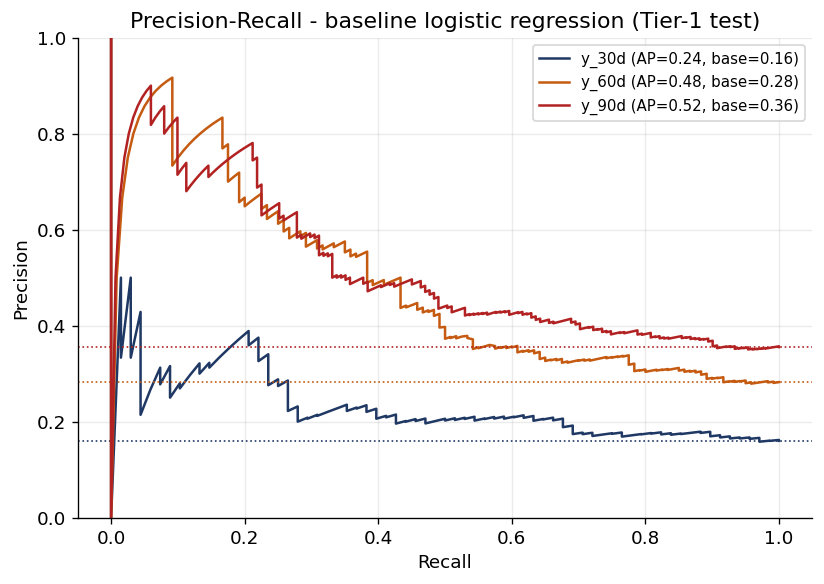

In [6]:
# Precision-recall curves vs the no-skill floor
fig,ax=plt.subplots(figsize=(7,5))
for h,col in zip(HORIZONS,[ACCENT,ORANGE,RED]):
    yte=test_t1['y_%dd'%h].values; proba=models[h].predict_proba(test_t1[FEATURES])[:,1]
    pr,rc,_=precision_recall_curve(yte,proba)
    ax.plot(rc,pr,color=col,label=f"y_{h}d (AP={average_precision_score(yte,proba):.2f}, base={yte.mean():.2f})")
    ax.axhline(yte.mean(),color=col,ls=':',lw=1)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_ylim(0,1); ax.legend(fontsize=9)
ax.set_title("Precision-Recall - baseline logistic regression (Tier-1 test)")
plt.savefig(FIG/"baseline_pr.png",bbox_inches='tight'); plt.show()

Because the features are standardised, the elastic-net coefficients are comparable log-odds effects.
Cross-window coefficients of a family should be read jointly (they are correlated by construction).

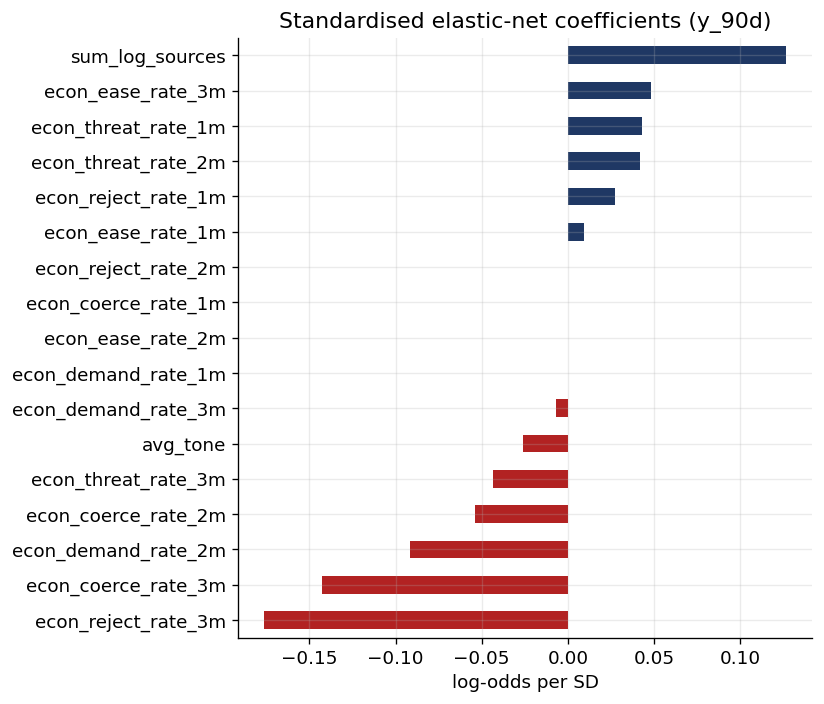

Non-zero coefficients (y_90d): 13 of 17 | L1 has zeroed 4


In [7]:
h=90; best=models[h].best_estimator_
coef=pd.Series(best.named_steps['lr'].coef_[0], index=FEATURES).sort_values()
fig,ax=plt.subplots(figsize=(7,6))
coef.plot.barh(ax=ax,color=[RED if v<0 else ACCENT for v in coef.values])
ax.set_title(f"Standardised elastic-net coefficients (y_{h}d)"); ax.set_xlabel("log-odds per SD")
plt.savefig(FIG/"baseline_coef.png",bbox_inches='tight'); plt.show()
print("Non-zero coefficients (y_90d):", int((coef!=0).sum()), "of", len(coef),
      "| L1 has zeroed", int((coef==0).sum()))

Rolling-origin backtesting 

A single test window can be flattered or penalised by which episode it happens to contain (the 2025
surge inflates precision here). Rolling-origin evaluation - repeatedly training on all data up to a
cut-off and testing on the next block, then rolling the cut-off forward - averages performance over
several forward periods and is the recommended way to estimate a forecaster's skill

In [8]:
def rolling_origin(h, n_folds=4, test_months=6):
    months=np.sort(data['month'].unique())
    results=[]
    # place fold cut-offs so each test block is `test_months` long, ending at the series end
    for k in range(n_folds,0,-1):
        cut=months[-(k*test_months)]
        tr=data[data['month']<cut]
        te=data[(data['month']>=cut)&(data['month']<months[-((k-1)*test_months)] if (k-1)>0 else data['month']<=months[-1])]
        te=te[te['tier']=='T1']
        if tr['y_%dd'%h].sum()<10 or te['y_%dd'%h].sum()<3: continue
        pipe=Pipeline([("scale",StandardScaler()),
              ("lr",LogisticRegression(penalty="elasticnet",solver="saga",l1_ratio=0.5,C=0.1,
                    class_weight="balanced",max_iter=3000,random_state=0))])
        pipe.fit(tr[FEATURES],tr['y_%dd'%h].values)
        pr=pipe.predict_proba(te[FEATURES])[:,1]; y=te['y_%dd'%h].values
        results.append({"cutoff":str(pd.Timestamp(cut).date()),"n_test":len(te),"pos_rate":y.mean(),
            "PR_AUC":average_precision_score(y,pr),"lift":average_precision_score(y,pr)-y.mean(),
            "ROC_AUC":roc_auc_score(y,pr)})
    return pd.DataFrame(results)

bt_summary=[]
for h in HORIZONS:
    bt=rolling_origin(h)
    bt_summary.append({"horizon":f"y_{h}d","folds":len(bt),
        "mean_PR_AUC_lift":round(bt['lift'].mean(),3),"sd_lift":round(bt['lift'].std(),3),
        "mean_ROC_AUC":round(bt['ROC_AUC'].mean(),3)})
    print(f"y_{h}d rolling-origin ({len(bt)} folds):"); print(bt.round(3).to_string(index=False)); print()
bt_df=pd.DataFrame(bt_summary); print("SUMMARY:"); print(bt_df.to_string(index=False))

y_30d rolling-origin (3 folds):
    cutoff  n_test  pos_rate  PR_AUC  lift  ROC_AUC
2024-08-01     102     0.098   0.160 0.062    0.609
2025-02-01     102     0.284   0.365 0.080    0.573
2025-08-01     102     0.284   0.443 0.159    0.643



y_60d rolling-origin (3 folds):
    cutoff  n_test  pos_rate  PR_AUC  lift  ROC_AUC
2024-08-01     102     0.225   0.386 0.160    0.570
2025-02-01     102     0.471   0.747 0.276    0.774
2025-08-01     102     0.480   0.689 0.209    0.683



y_90d rolling-origin (3 folds):
    cutoff  n_test  pos_rate  PR_AUC  lift  ROC_AUC
2024-08-01     102     0.333   0.511 0.178    0.564
2025-02-01     102     0.549   0.747 0.198    0.714
2025-08-01     102     0.598   0.809 0.211    0.721

SUMMARY:
horizon  folds  mean_PR_AUC_lift  sd_lift  mean_ROC_AUC
  y_30d      3             0.100    0.051         0.608
  y_60d      3             0.215    0.058         0.676
  y_90d      3             0.196    0.017         0.666


In [9]:
res.to_csv(DATA/"baseline_results.csv",index=False)
bt_df.to_csv(DATA/"baseline_backtest.csv",index=False)
print("saved -> data/baseline_results.csv and data/baseline_backtest.csv")
print("\nSingle-split (Tier-1 test):"); print(res.to_string(index=False))
print("\nRolling-origin summary:"); print(bt_df.to_string(index=False))

saved -> data/baseline_results.csv and data/baseline_backtest.csv

Single-split (Tier-1 test):
horizon  pos_rate  PR_AUC  PR_AUC_lift  ROC_AUC   MCC  bal_acc    F1  Brier
  y_30d     0.160   0.237        0.077    0.597 0.111    0.575 0.302  0.239
  y_60d     0.282   0.483        0.201    0.638 0.138    0.577 0.445  0.238
  y_90d     0.355   0.516        0.160    0.613 0.137    0.571 0.504  0.243

Rolling-origin summary:
horizon  folds  mean_PR_AUC_lift  sd_lift  mean_ROC_AUC
  y_30d      3             0.100    0.051         0.608
  y_60d      3             0.215    0.058         0.676
  y_90d      3             0.196    0.017         0.666
